In [46]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, scipy.io as sio
import os, glob
from neo.io import BlackrockIO
import h5py

# Notes
preprocess (mostly notch filter) raw .mat

### global variables and functions

In [47]:
patient = 22

### lets consider example patient and channel

In [48]:
# load
chan_mat_files = glob.glob(f'../../results/*{patient}/osort_mat/nsx2mat/*.mat')
print(f'{len(chan_mat_files)} channels: ', end='')
for chan_mat_file in sorted(chan_mat_files):
    print(chan_mat_file.split('BL')[1].split('.mat')[0], end=', ')
# chan_mat_files

32 channels: 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 

#samples: 50569506
sampling freq: 30000.0
signal dur: 1685.6502


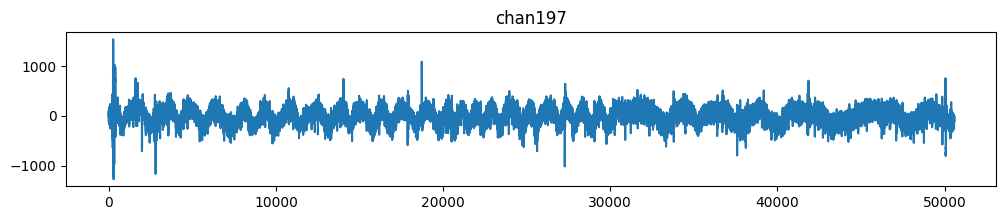

In [49]:
# example channel signal
chanID = 197
chan_mat_file = glob.glob(f'../../results/2025{patient}/osort_mat/nsx2mat/*{chanID}*.mat')[0]

# load
with h5py.File(chan_mat_file, "r") as f:

    raw_sig = np.array(f["data"]).squeeze()
    sig_freq = float(np.array(f["MetaTags/SamplingFreq"]).squeeze())
    sig_dur = raw_sig.shape[0] / sig_freq

print(f'#samples: {raw_sig.shape[0]}')
print(f'sampling freq: {sig_freq}')
print(f'signal dur: {sig_dur}')
every_nth = 1000  # for plotting
plt.figure(figsize=(12,2))
plt.plot(raw_sig[::every_nth])  # downsample for faster plotting
plt.title(f'chan{chanID}')
plt.show()

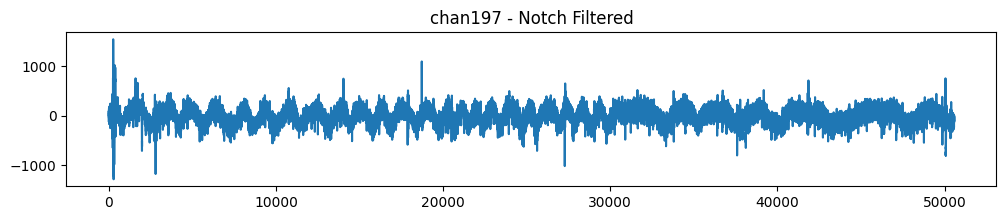

In [50]:
# notch filter at 60 Hz
from scipy.signal import iirnotch, filtfilt

def notch_filter(data, fs, freqs=[60.0, 120.0, 180.0], quality=30.0):
    for freq in freqs:
        b, a = iirnotch(freq, quality, fs)
        filtered_data = filtfilt(b, a, data)
    return filtered_data

filtered_sig = notch_filter(raw_sig, sig_freq)
plt.figure(figsize=(12,2))
plt.plot(filtered_sig[::every_nth])  # downsample for faster plotting
plt.title(f'chan{chanID} - Notch Filtered')
plt.show()


### great, now lets notch filter all channels and patients, and save

In [ ]:
all_chan_mats = glob.glob(f'../../results/*/osort_mat/nsx2mat/*.mat')
print(len(all_chan_mats), 'total channels')

for chan_mat in sorted(all_chan_mats): # parse through all files
    patient = chan_mat.split('2025')[1].split('/')[0]
    chanID = int(chan_mat.split('BL')[1].split('.mat')[0])

    # load .mat
    with h5py.File(chan_mat, "r") as f:
        raw_sig = np.array(f["data"]).squeeze()
        sig_freq = float(np.array(f["MetaTags/SamplingFreq"]).squeeze())

    # filter
    filtered_sig = notch_filter(raw_sig, sig_freq)
    
    # save
    out_dir = f'../../results/2025{patient}/osort_mat/nsx2mat_clean/'
    os.makedirs(out_dir, exist_ok=True)
    out_file = f'{out_dir}BL{chanID}.mat'
    sio.savemat(out_file, {'data': filtered_sig, 'MetaTags/SamplingFreq': sig_freq})
    print(f'pt{patient}/chan{chanID}', end=', ')

print('done')

128 total channels
pt12/chan100, pt12/chan101, pt12/chan102, pt12/chan103, pt12/chan104, pt12/chan105, pt12/chan106, pt12/chan107, pt12/chan108, pt12/chan109, pt12/chan110, pt12/chan111, pt12/chan112, pt12/chan113, pt12/chan114, pt12/chan115, pt12/chan116, pt12/chan117, pt12/chan118, pt12/chan119, pt12/chan120, pt12/chan121, pt12/chan122, pt12/chan123, pt12/chan124, pt12/chan125, pt12/chan126, pt12/chan127, pt12/chan128, pt12/chan97, pt12/chan98, pt12/chan99, pt18/chan193, pt18/chan194, pt18/chan195, pt18/chan196, pt18/chan197, pt18/chan198, pt18/chan199, pt18/chan200, pt18/chan201, pt18/chan202, pt18/chan203, pt18/chan204, pt18/chan205, pt18/chan206, pt18/chan207, pt18/chan208, pt18/chan209, pt18/chan210, pt18/chan211, pt18/chan212, pt18/chan213, pt18/chan214, pt18/chan215, pt18/chan216, pt18/chan217, pt18/chan218, pt18/chan219, pt18/chan220, pt18/chan221, pt18/chan222, pt18/chan223, pt18/chan224, pt21/chan193, pt21/chan194, pt21/chan195, 